In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
# parameters
n_states = 11
n_actions = 3
gamma = 0.95
theta = 1e-6

In [2]:
def build_transition_matrices(n_states):

    P_hover = np.zeros((n_states,n_states))
    P_descent = np.zeros((n_states,n_states))
    P_boost = np.zeros((n_states,n_states))

    # terminal state
    for P in [P_hover,P_descent,P_boost]:
        P[10,10] = 1

    # hover
    for s in range(10):
        P_hover[s,s] += 0.6
        P_hover[s,min(s+1,10)] += 0.4

    # controlled descent
    for s in range(10):
        P_descent[s,max(s-1,0)] += 0.48
        P_descent[s,s] += 0.44
        P_descent[s,min(s+1,10)] += 0.08

    # emergency boost
    for s in range(10):
        target = max(s-3,0)

        if s <= 6:
            P_boost[s,target] = 1
        else:
            P_boost[s,target] = 0.75
            P_boost[s,10] = 0.25

    return np.stack([P_hover,P_descent,P_boost])

In [3]:
def build_reward_matrix(n_states,n_actions):

    R = np.zeros((n_states,n_actions))

    state_reward = np.zeros(n_states)
    state_reward[0:4] = -5
    state_reward[4:7] = 20
    state_reward[7:10] = -5
    state_reward[10] = -500

    action_cost = [0,-2,-8]

    for s in range(n_states):
        for a in range(n_actions):
            R[s,a] = state_reward[s] + action_cost[a]

    R[10,:] = -500

    return R

In [4]:
def value_iteration(P,R,gamma,theta):

    n_states = R.shape[0]
    n_actions = R.shape[1]

    V = np.zeros(n_states)
    diff_history = []

    while True:

        V_new = np.zeros(n_states)

        for s in range(n_states):

            action_values = []

            for a in range(n_actions):

                expected_value = np.sum(P[a,s,:] * (R[s,a] + gamma*V))
                action_values.append(expected_value)

            V_new[s] = max(action_values)

        diff = np.max(np.abs(V_new - V))
        diff_history.append(diff)

        V = V_new.copy()

        if diff < theta:
            break

    policy = np.zeros(n_states)

    for s in range(n_states):

        action_values = []

        for a in range(n_actions):

            expected_value = np.sum(P[a,s,:]*(R[s,a] + gamma*V))
            action_values.append(expected_value)

        policy[s] = np.argmax(action_values)

    return V, policy, diff_history

In [25]:
def compute_action_value_function(P, R, V, gamma):

    n_states = R.shape[0]
    n_actions = R.shape[1]

    Q = np.zeros((n_states, n_actions))

    for s in range(n_states):

        for a in range(n_actions):

            Q[s,a] = np.sum(P[a,s,:] * (R[s,a] + gamma * V))

    return Q

In [5]:
def policy_iteration(P,R,gamma,theta):

    n_states = R.shape[0]
    n_actions = R.shape[1]

    policy = np.random.randint(0,n_actions,size=n_states)
    V = np.zeros(n_states)

    while True:

        # policy evaluation
        while True:

            delta = 0

            for s in range(n_states):

                a = policy[s]

                v_new = np.sum(P[a,s,:]*(R[s,a] + gamma*V))

                delta = max(delta, abs(v_new - V[s]))

                V[s] = v_new

            if delta < theta:
                break

        # policy improvement
        policy_stable = True

        for s in range(n_states):

            old_action = policy[s]

            action_values = []

            for a in range(n_actions):

                val = np.sum(P[a,s,:]*(R[s,a] + gamma*V))
                action_values.append(val)

            best_action = np.argmax(action_values)

            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return V, policy

In [23]:
def plot_policy(policy):

    # ensure terminal state action is 0
    policy[10] = 0

    states = np.arange(11)

    plt.figure(figsize=(8,4))

    plt.bar(states, policy)

    plt.xlabel("State")
    plt.ylabel("Best Action")
    plt.title("Optimal Action per State")

    plt.xticks(states)
    plt.yticks([0,1,2])

    # show action value above bars
    for i, v in enumerate(policy):
        plt.text(i, v + 0.05, str(int(v)), ha='center')

    legend_elements = [
        Patch(facecolor='blue', label='0 = Hover'),
        Patch(facecolor='blue', label='1 = Controlled Descent'),
        Patch(facecolor='blue', label='2 = Emergency Boost'),
    ]

    plt.legend(handles=legend_elements)

    plt.show()

In [7]:
P = build_transition_matrices(n_states)
R = build_reward_matrix(n_states,n_actions)

In [8]:
V_vi, policy_vi, diff_history = value_iteration(P,R,gamma,theta)

print("Value Iteration Results")
print("Optimal Value Function:")
print(V_vi)

print("\nOptimal Policy:")
print(policy_vi)

Value Iteration Results
Optimal Value Function:
[  188.99923124   227.02544594   270.05510995   318.74657186
   373.84480507   370.40333212   356.59879223   271.53391652
    31.89066028 -1292.88291645 -9999.99998148]

Optimal Policy:
[0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0.]


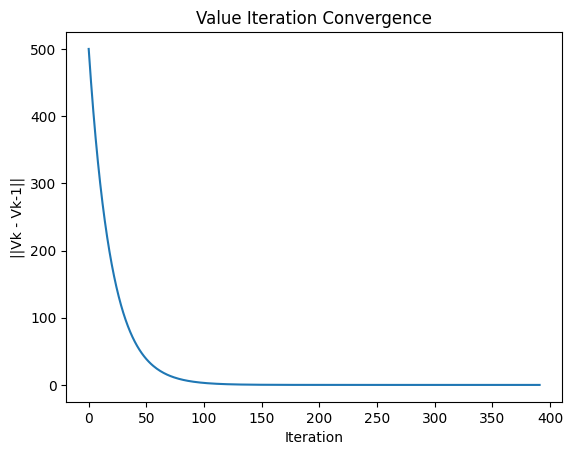

In [9]:
plt.plot(diff_history)
plt.xlabel("Iteration")
plt.ylabel("||Vk - Vk-1||")
plt.title("Value Iteration Convergence")
plt.show()

In [10]:
V_pi, policy_pi = policy_iteration(P,R,gamma,theta)

print("Policy Iteration Results")
print("Optimal Value Function:")
print(V_pi)

print("\nOptimal Policy:")
print(policy_pi)

Policy Iteration Results
Optimal Value Function:
[   188.9992178     227.02543306    270.05509761    318.74656002
    373.84479372    370.40332124    356.5987818     271.53390649
     31.89065045  -1292.8829272  -10000.        ]

Optimal Policy:
[0 0 0 0 0 1 1 1 1 1 0]


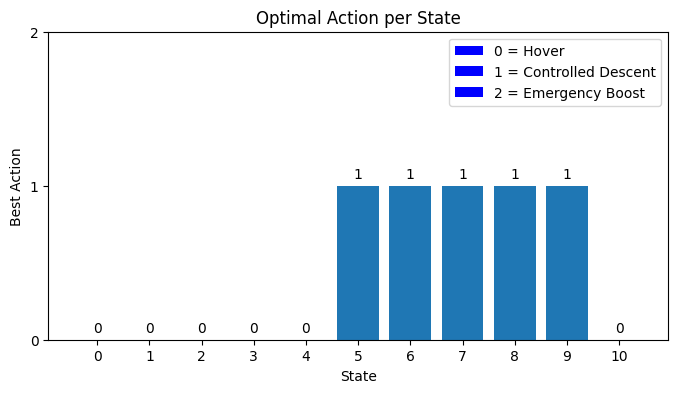

In [24]:
plot_policy(policy_vi)

In [26]:
Q = compute_action_value_function(P, R, V_vi, gamma)

print("Action Value Function Q*(s,a):")
print(Q)

Action Value Function Q*(s,a):
[[  188.99923126   175.43926199   166.54926967]
 [  227.02544597   194.6044742    166.54926967]
 [  270.05510998   233.63137877   166.54926967]
 [  318.74657188   277.79340236   166.54926967]
 [  373.84480509   347.76621853   227.67417364]
 [  366.63744035   370.40333215   268.55235445]
 [  326.44419985   356.59879225   314.80924326]
 [  161.89278332   271.53391654 -2121.63557199]
 [ -478.11783189    31.89066028 -2124.08762147]
 [-4541.94325534 -1292.88291658 -2133.92335614]
 [-9999.99998241 -9999.99998241 -9999.99998241]]


In [12]:
def display_transition_matrices(P):

    actions = ["Hover", "Controlled Descent", "Emergency Boost"]

    for a in range(3):

        df = pd.DataFrame(P[a],
                          columns=[f"s'={i}" for i in range(11)],
                          index=[f"s={i}" for i in range(11)])

        print(f"\nTransition Matrix for Action: {actions[a]}")
        display(df)

In [13]:
def display_reward_matrix(R):

    actions = ["Hover", "Descent", "Boost"]

    df = pd.DataFrame(R,
                      columns=actions,
                      index=[f"s={i}" for i in range(11)])

    print("Reward Matrix R(s,a)")
    display(df)

In [28]:
display_transition_matrices(P)
display_reward_matrix(R)

df_Q = pd.DataFrame(Q,
                    columns=["Hover (0)", "Descent (1)", "Boost (2)"],
                    index=[f"State {i}" for i in range(11)])
print("Action Value Function Q*(s,a):")
display(df_Q)


Transition Matrix for Action: Hover


,s'=0,s'=1,s'=2,s'=3,s'=4,s'=5,s'=6,s'=7,s'=8,s'=9,s'=10
s=0,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s=1,0.0,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s=2,0.0,0.0,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s=3,0.0,0.0,0.0,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0
s=4,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.0,0.0,0.0,0.0
s=5,0.0,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.0,0.0,0.0
s=6,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.0,0.0
s=7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.0
s=8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4,0.0
s=9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4



Transition Matrix for Action: Controlled Descent


,s'=0,s'=1,s'=2,s'=3,s'=4,s'=5,s'=6,s'=7,s'=8,s'=9,s'=10
s=0,0.92,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
s=1,0.48,0.44,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
s=2,0.00,0.48,0.44,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00
s=3,0.00,0.00,0.48,0.44,0.08,0.00,0.00,0.00,0.00,0.00,0.00
s=4,0.00,0.00,0.00,0.48,0.44,0.08,0.00,0.00,0.00,0.00,0.00
s=5,0.00,0.00,0.00,0.00,0.48,0.44,0.08,0.00,0.00,0.00,0.00
s=6,0.00,0.00,0.00,0.00,0.00,0.48,0.44,0.08,0.00,0.00,0.00
s=7,0.00,0.00,0.00,0.00,0.00,0.00,0.48,0.44,0.08,0.00,0.00
s=8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.48,0.44,0.08,0.00
s=9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.48,0.44,0.08



Transition Matrix for Action: Emergency Boost


,s'=0,s'=1,s'=2,s'=3,s'=4,s'=5,s'=6,s'=7,s'=8,s'=9,s'=10
s=0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=1,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=2,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=3,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=4,0.0,1.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=5,0.0,0.0,1.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=6,0.0,0.0,0.0,1.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00
s=7,0.0,0.0,0.0,0.0,0.75,0.00,0.00,0.0,0.0,0.0,0.25
s=8,0.0,0.0,0.0,0.0,0.00,0.75,0.00,0.0,0.0,0.0,0.25
s=9,0.0,0.0,0.0,0.0,0.00,0.00,0.75,0.0,0.0,0.0,0.25


Reward Matrix R(s,a)


,Hover,Descent,Boost
s=0,-5.0,-7.0,-13.0
s=1,-5.0,-7.0,-13.0
s=2,-5.0,-7.0,-13.0
s=3,-5.0,-7.0,-13.0
s=4,20.0,18.0,12.0
s=5,20.0,18.0,12.0
s=6,20.0,18.0,12.0
s=7,-5.0,-7.0,-13.0
s=8,-5.0,-7.0,-13.0
s=9,-5.0,-7.0,-13.0


Action Value Function Q*(s,a):


,Hover (0),Descent (1),Boost (2)
State 0,188.999231,175.439262,166.549270
State 1,227.025446,194.604474,166.549270
State 2,270.055110,233.631379,166.549270
State 3,318.746572,277.793402,166.549270
State 4,373.844805,347.766219,227.674174
State 5,366.637440,370.403332,268.552354
State 6,326.444200,356.598792,314.809243
State 7,161.892783,271.533917,-2121.635572
State 8,-478.117832,31.890660,-2124.087621
State 9,-4541.943255,-1292.882917,-2133.923356


,Hover (0),Descent (1),Boost (2)
State 0,188.999231,175.439262,166.549270
State 1,227.025446,194.604474,166.549270
State 2,270.055110,233.631379,166.549270
State 3,318.746572,277.793402,166.549270
State 4,373.844805,347.766219,227.674174
State 5,366.637440,370.403332,268.552354
State 6,326.444200,356.598792,314.809243
State 7,161.892783,271.533917,-2121.635572
State 8,-478.117832,31.890660,-2124.087621
State 9,-4541.943255,-1292.882917,-2133.923356
